In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from tqdm import tqdm

In [3]:
def intervals_overlap(a, b):
    """Verifica se os intervalos a e b se sobrepõem"""
    return max(a[0], b[0]) <= min(a[1], b[1])

def match_event_intervals(y_true, y_pred):
    """
    Compara listas de intervalos (eventos reais e previstos).
    Cada intervalo é uma tupla: (inicio, fim)

    Retorna TP, FP, FN
    """
    matched = set()

    for i, pred in enumerate(y_pred):
        for j, true in enumerate(y_true):
            if intervals_overlap(pred, true):
                matched.add(j)
                break  # conta só uma correspondência

    TP = len(matched)
    FP = len(y_pred) - TP
    FN = len(y_true) - TP

    return TP, FP, FN

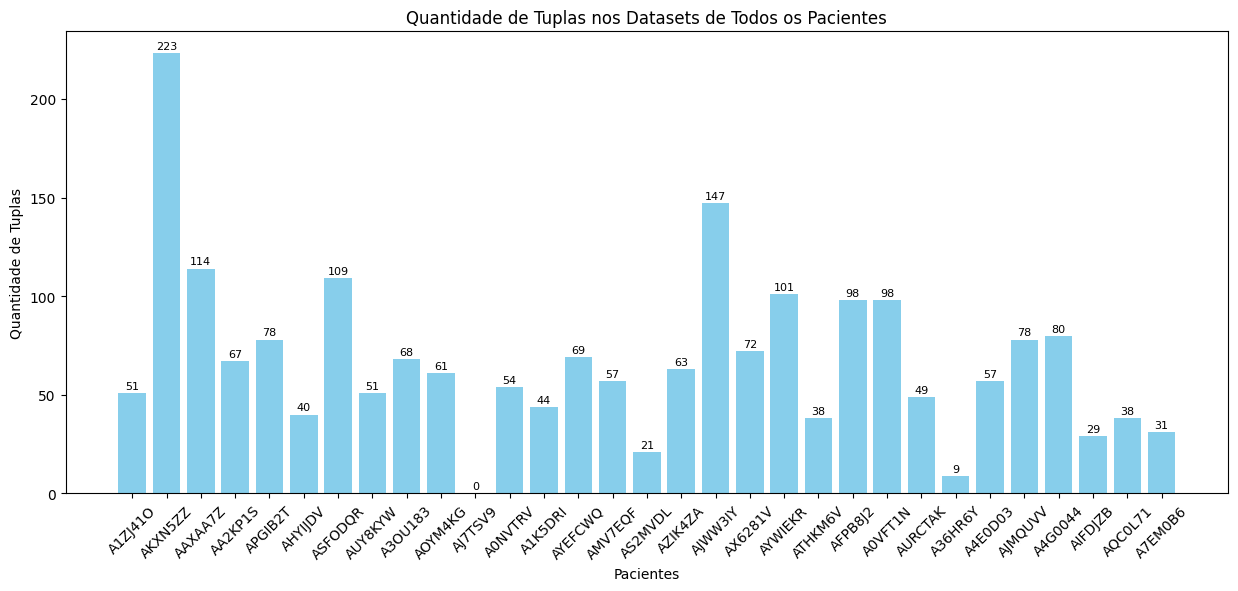

In [4]:

patients = [patient for patient in os.listdir("Patients/RHR") if os.path.isdir(os.path.join("Patients/RHR", patient))]
len(patients)
# Criar um dicionário para armazenar a quantidade de tuplas por paciente
tuples_count = {}

# Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
for patient in patients:
    try:
        df_full = pd.read_csv(f'Patients/RHR/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
        tuples_count[patient] = len(df_full)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        tuples_count[patient] = 0
        patients.remove(patient)

# Plotar os resultados
plt.figure(figsize=(15, 6))
plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
plt.xlabel('Pacientes')
plt.ylabel('Quantidade de Tuplas')
plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
plt.xticks(rotation=45)
# Adicionar os valores absolutos acima de cada barra
for i, (patient, count) in enumerate(tuples_count.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)

In [ ]:
n = 5

metrics_table_mec = {mec: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1 Score']) 
                     for mec in ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']}
mr_values = ["05", "10", "15", "20", "25"]

for mec in ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']:

    results = {}
    absolute = {}

    # Adicionar barra de progresso
    for patient in tqdm(patients, desc=f"Processando pacientes para {mec}"):
        
        # Carregar df_full
        try:
            df_full = pd.read_csv(f'Patients/RHR/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
        except (FileNotFoundError, pd.errors.EmptyDataError):
            print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
            continue
        
        # Inicializar dfs_miss
        dfs_miss = {}
        for mr_value in mr_values:
            dfs_miss[mr_value] = {}
            for i in range(1, n + 1):
                file_path = f'Patients/RHR/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'
                if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                    dfs_miss[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                else:
                    if not os.path.exists(file_path):
                        continue
                    elif os.path.getsize(file_path) == 0:
                        dfs_miss[mr_value][i] = pd.DataFrame(columns=[1, 2])  

        precision_list = {mr: [] for mr in mr_values}
        recall_list = {mr: [] for mr in mr_values}

        for mr, dfs in dfs_miss.items():
            for key, df_miss in dfs.items():
                y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_full[1], df_full[1])]
                y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_miss[1], df_miss[1])]

                TP, FP, FN = match_event_intervals(y_true_intervals, y_pred_intervals)

                if mr not in absolute:
                    absolute[mr] = {'TP': [], 'FP': [], 'FN': []}
                absolute[mr]['TP'].append(TP)
                absolute[mr]['FP'].append(FP)
                absolute[mr]['FN'].append(FN)

                precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                precision_list[mr].append(precision)
                recall_list[mr].append(recall)

        mean_precision_by_mr = {mr: [] for mr in mr_values}
        mean_recall_by_mr = {mr: [] for mr in mr_values}

        for mr in mr_values:
            precision_sum = sum(precision_list[mr])
            recall_sum = sum(recall_list[mr])
            count = len(precision_list[mr])

            mean_precision_by_mr[mr] = precision_sum / count if count > 0 else 0
            mean_recall_by_mr[mr] = recall_sum / count if count > 0 else 0

        for mr in mr_values:
            if mr not in results:
                results[mr] = {'precision': [], 'recall': []}
            results[mr]['precision'].append(mean_precision_by_mr[mr])
            results[mr]['recall'].append(mean_recall_by_mr[mr])

    # Inicializar os valores totais de TP, FP, FN
    # Inicializar os valores totais de TP, FP, FN por MR
    total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute.items()}
    total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute.items()}
    total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute.items()}

    # Inicializar listas para armazenar as métricas
    accuracy_list = []
    precision_list = []
    f1_list = []
    recall_list = []

    # Calcular métricas para cada MR
    for mr in mr_values:
        tp = total_tp_by_mr[mr]
        fp = total_fp_by_mr[mr]
        fn = total_fn_by_mr[mr]
        total_instances = tp + fp + fn

        # Calcular acurácia, precisão, revocação e F1
        accuracy = tp / total_instances if total_instances > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Adicionar métricas às listas
        accuracy_list.append(accuracy * 100)
        precision_list.append(precision * 100)
        recall_list.append(recall * 100)
        f1_list.append(f1 * 100)

    # Criar um DataFrame com as métricas
    metrics_table = pd.DataFrame({
        'MR': mr_values,
        'Accuracy': accuracy_list,
        'Precision': precision_list,
        'Recall': recall_list,
        'F1 Score': f1_list
    })

    # Adicionar a tabela de métricas ao DataFrame geral
    metrics_table_mec[mec] = metrics_table

    # Exibir a tabela
    print(metrics_table)
metrics_table_mec.to_csv('Results/RHR_metrics.csv', index=False)

Processando pacientes para MCAR: 100%|██████████| 31/31 [02:25<00:00,  4.68s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  79.381188  89.281737  87.742818  88.505589
1  10  68.475533  83.011693  79.635203  81.288401
2  15  60.450355  77.904372  72.959416  75.350852
3  20  53.898949  72.995155  67.323301  70.044596
4  25  48.220551  69.180193  61.413589  65.065945


Processando pacientes para MAR_l: 100%|██████████| 31/31 [02:11<00:00,  4.25s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  72.708590  88.053758  80.665755  84.198001
1  10  57.370054  79.345494  67.441860  72.911018
2  15  46.096096  72.277810  55.996352  63.103803
3  20  36.910509  66.532798  45.326037  53.919175
4  25  28.603269  60.677699  35.111719  44.482958


Processando pacientes para MAR_h: 100%|██████████| 31/31 [02:22<00:00,  4.60s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  75.766363  89.219512  83.401733  86.212585
1  10  63.746106  81.361829  74.646603  77.859691
2  15  55.712110  77.162447  66.712266  71.557838
3  20  50.867925  74.681440  61.468308  67.433717
4  25  46.156716  71.751740  56.406749  63.160582


Processando pacientes para MNAR_l: 100%|██████████| 31/31 [02:34<00:00,  4.98s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  71.601769  76.658777  91.564067  83.451085
1  10  59.924767  69.461964  81.358869  74.941196
2  15  49.720082  64.153990  68.846329  66.417385
3  20  44.079035  61.755690  60.629275  61.187299
4  25  38.909440  60.990014  51.801186  56.021304


Processando pacientes para MNAR_h: 100%|██████████| 31/31 [02:20<00:00,  4.53s/it]

   MR   Accuracy  Precision     Recall   F1 Score
0  05  78.189740  88.804855  86.739626  87.760092
1  10  66.474034  83.436010  76.580027  79.861144
2  15  56.289947  76.232179  68.271774  72.032716
3  20  47.781195  70.800781  59.507524  64.664784
4  25  41.784311  67.402277  52.366621  58.940669


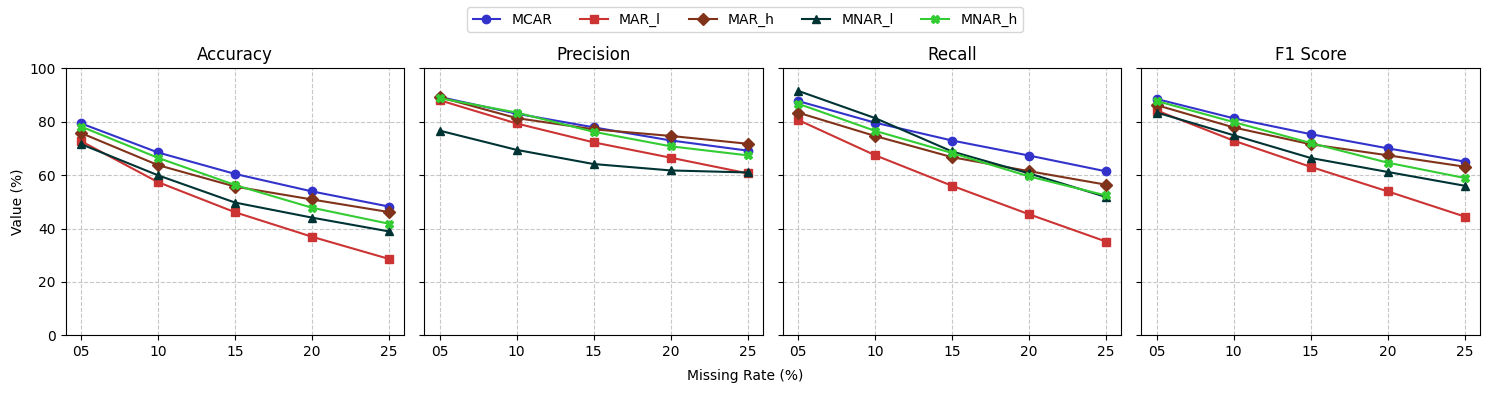

In [27]:
# Trocar o eixo x para mostrar as métricas e cada linha ser um mecanismo
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

colors = {'MCAR': (0.2, 0.2, 0.8), 'MAR_l': (0.8, 0.2, 0.2), 
          'MAR_h': (0.5, 0.2, 0.1),'MNAR_l': (0.0, 0.2, 0.2), 'MNAR_h':(0.2, 0.8, 0.2)}
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_h': 'D', 'MNAR_l': '^', 'MNAR_h': 'X'}

fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for idx, metric in enumerate(metric_names):
    for mec_name, table in metrics_table_mec.items():
        axs[idx].plot(table['MR'], table[metric], marker=markers.get(mec_name, 'o'), label=mec_name, color=colors.get(mec_name, 'black'))
    axs[idx].set_title(metric)
    axs[idx].set_ylim(0, 100)
    axs[idx].set_xticks(mr_values)
    #axs[idx].set_xlabel('Missing Rate (%)')
    axs[idx].set_ylabel('Value (%)' if idx == 0 else "")
    axs[idx].grid(True)

fig.supxlabel('Missing Rate (%)', fontsize=10, y=0.05)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=10)
for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('Plots/metrics_RHR_cont.png', dpi=600, bbox_inches='tight')
plt.show()

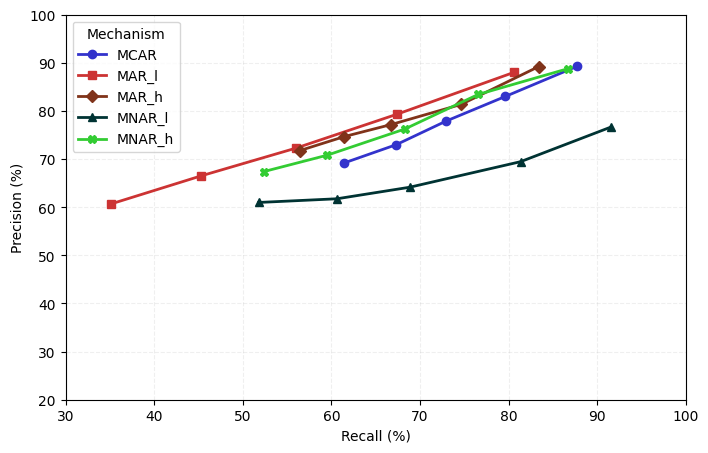

In [20]:
plt.figure(figsize=(8, 5))
for mec_name, table in metrics_table_mec.items():
    plt.plot(table['Recall'], table['Precision'], label=mec_name, marker=markers.get(mec_name, 'o'), color=colors.get(mec_name, 'black'), linewidth=2)
    # for i, row in table.iterrows():
    #     if mec_name == 'MAR':
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8)
    #     elif mec_name == 'MCAR':
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8)
    #     else:
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8)
plt.xlabel('Recall (%)')
plt.ylabel('Precision (%)')
plt.ylim(20, 100)
plt.xlim(30,100)
plt.grid(True, linestyle='--', alpha=0.2)
plt.legend(loc='upper left', title='Mechanism')
plt.savefig('Plots/precision_recall_plot_RHR.png', dpi=300, bbox_inches='tight')
plt.show()

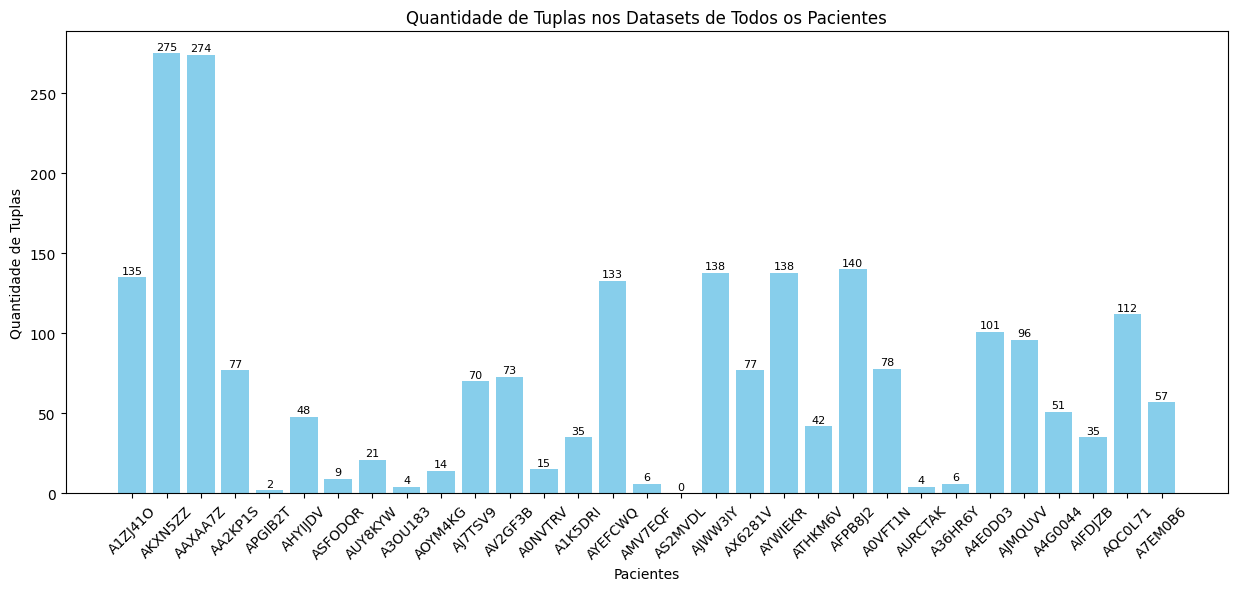

In [5]:

patients = [patient for patient in os.listdir("Patients/HROS") if os.path.isdir(os.path.join("Patients/HROS", patient))]
len(patients)

# Criar um dicionário para armazenar a quantidade de tuplas por paciente
tuples_count = {}

# Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
for patient in patients:
    try:
        df_full = pd.read_csv(f'Patients/HROS/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
        tuples_count[patient] = len(df_full)
    except (FileNotFoundError, pd.errors.EmptyDataError):
        tuples_count[patient] = 0
        patients.remove(patient)
        

# Plotar os resultados
plt.figure(figsize=(15, 6))
plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
plt.xlabel('Pacientes')
plt.ylabel('Quantidade de Tuplas')
plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
plt.xticks(rotation=45)
# Adicionar os valores absolutos acima de cada barra
for i, (patient, count) in enumerate(tuples_count.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)

In [6]:
n = 5

metrics_table_mec = {mec: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1 Score']) 
                     for mec in ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']}

mr_values = ["05", "10", "15", "20", "25"]

for mec in ['MCAR', 'MAR_l', 'MAR_h', 'MNAR_l', 'MNAR_h']:

    results = {}
    absolute = {}

    # Adicionar barra de progresso
    for patient in tqdm(patients, desc=f"Processando pacientes para {mec}"):
        # print(f"Processando paciente: {patient}")
        
        # Carregar df_full
        try:
            df_full = pd.read_csv(f'Patients/HROS/{patient}/Anomalies/{patient}_original_anomalies.csv', header=None)
        except (FileNotFoundError, pd.errors.EmptyDataError):
            print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
            continue
        
        # Inicializar dfs_miss
        dfs_miss = {}
        for mr_value in mr_values:
            dfs_miss[mr_value] = {}
            for i in range(1, n + 1):
                file_path = f'Patients/HROS/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'
                if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                    dfs_miss[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                else:
                    if not os.path.exists(file_path):
                        continue
                    elif os.path.getsize(file_path) == 0:
                        dfs_miss[mr_value][i] = pd.DataFrame(columns=[1, 2])  

        precision_list = {mr: [] for mr in mr_values}
        recall_list = {mr: [] for mr in mr_values}

        for mr, dfs in dfs_miss.items():
            for key, df_miss in dfs.items():
                y_true_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_full[1], df_full[1])]
                y_pred_intervals = [(pd.to_datetime(start), pd.to_datetime(end)) for start, end in zip(df_miss[1], df_miss[1])]

                TP, FP, FN = match_event_intervals(y_true_intervals, y_pred_intervals)

                if mr not in absolute:
                    absolute[mr] = {'TP': [], 'FP': [], 'FN': []}
                absolute[mr]['TP'].append(TP)
                absolute[mr]['FP'].append(FP)
                absolute[mr]['FN'].append(FN)

                precision = TP / (TP + FP) if (TP + FP) > 0 else 0
                recall = TP / (TP + FN) if (TP + FN) > 0 else 0

                precision_list[mr].append(precision)
                recall_list[mr].append(recall)

        mean_precision_by_mr = {mr: [] for mr in mr_values}
        mean_recall_by_mr = {mr: [] for mr in mr_values}

        for mr in mr_values:
            precision_sum = sum(precision_list[mr])
            recall_sum = sum(recall_list[mr])
            count = len(precision_list[mr])

            mean_precision_by_mr[mr] = precision_sum / count if count > 0 else 0
            mean_recall_by_mr[mr] = recall_sum / count if count > 0 else 0

        for mr in mr_values:
            if mr not in results:
                results[mr] = {'precision': [], 'recall': []}
            results[mr]['precision'].append(mean_precision_by_mr[mr])
            results[mr]['recall'].append(mean_recall_by_mr[mr])

    # Inicializar os valores totais de TP, FP, FN
    # Inicializar os valores totais de TP, FP, FN por MR
    total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute.items()}
    total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute.items()}
    total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute.items()}

    # Inicializar listas para armazenar as métricas
    accuracy_list = []
    precision_list = []
    f1_list = []
    recall_list = []

    # Calcular métricas para cada MR
    for mr in mr_values:
        tp = total_tp_by_mr[mr]
        fp = total_fp_by_mr[mr]
        fn = total_fn_by_mr[mr]
        total_instances = tp + fp + fn

        # Calcular acurácia, precisão, revocação e F1
        accuracy = tp / total_instances if total_instances > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        # Adicionar métricas às listas
        accuracy_list.append(accuracy * 100)
        precision_list.append(precision * 100)
        recall_list.append(recall * 100)
        f1_list.append(f1 * 100)

    # Criar um DataFrame com as métricas
    metrics_table = pd.DataFrame({
        'MR': mr_values,
        'Accuracy': accuracy_list,
        'Precision': precision_list,
        'Recall': recall_list,
        'F1 Score': f1_list
    })

    # Adicionar a tabela de métricas ao DataFrame geral
    metrics_table_mec[mec] = metrics_table

    # Exibir a tabela
    print(metrics_table)

Processando pacientes para MCAR:   0%|          | 0/31 [00:00<?, ?it/s]

Processando pacientes para MCAR: 100%|██████████| 31/31 [02:51<00:00,  5.53s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  80.354716  89.644168  88.577060  89.107419
1  10  69.477098  82.928796  81.072132  81.989955
2  15  61.651210  77.663399  74.938904  76.276830
3  20  56.434893  74.011440  70.382341  72.151285
4  25  52.249770  70.045137  67.284194  68.636912


Processando pacientes para MAR_l: 100%|██████████| 31/31 [02:41<00:00,  5.20s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  74.784483  89.394590  82.065432  85.573366
1  10  63.326446  83.363554  72.487190  77.545857
2  15  54.702886  79.791976  63.500197  70.719930
3  20  47.500000  75.476695  56.168703  64.406780
4  25  41.972477  71.325167  50.492708  59.127625


...

   MR   Accuracy  Precision     Recall   F1 Score
0  05  74.982105  89.073129  82.577848  85.702598
1  10  62.414501  82.504521  71.935357  76.858286
2  15  53.309305  75.957049  64.130863  69.544775
3  20  46.975674  73.888314  56.326370  63.923060
4  25  39.513289  67.802198  48.640126  56.644480


Processando pacientes para MNAR_l: 100%|██████████| 31/31 [02:45<00:00,  5.34s/it]


   MR   Accuracy  Precision     Recall   F1 Score
0  05  82.025316  90.865385  89.396926  90.125174
1  10  73.677127  87.898251  81.994482  84.843788
2  15  66.217244  84.341700  75.498620  79.675541
3  20  58.538750  81.391816  67.583760  73.847877
4  25  51.443326  76.258710  61.253449  67.937396


Processando pacientes para MNAR_h: 100%|██████████| 31/31 [02:30<00:00,  4.85s/it]

   MR   Accuracy  Precision     Recall   F1 Score
0  05  46.765181  68.766548  59.377217  63.727896
1  10  34.454687  58.872865  45.376429  51.251002
2  15  27.208169  51.568409  36.547103  42.777393
3  20  22.963475  46.033029  31.422940  37.350075
4  25  20.585847  43.793189  27.977927  34.143056


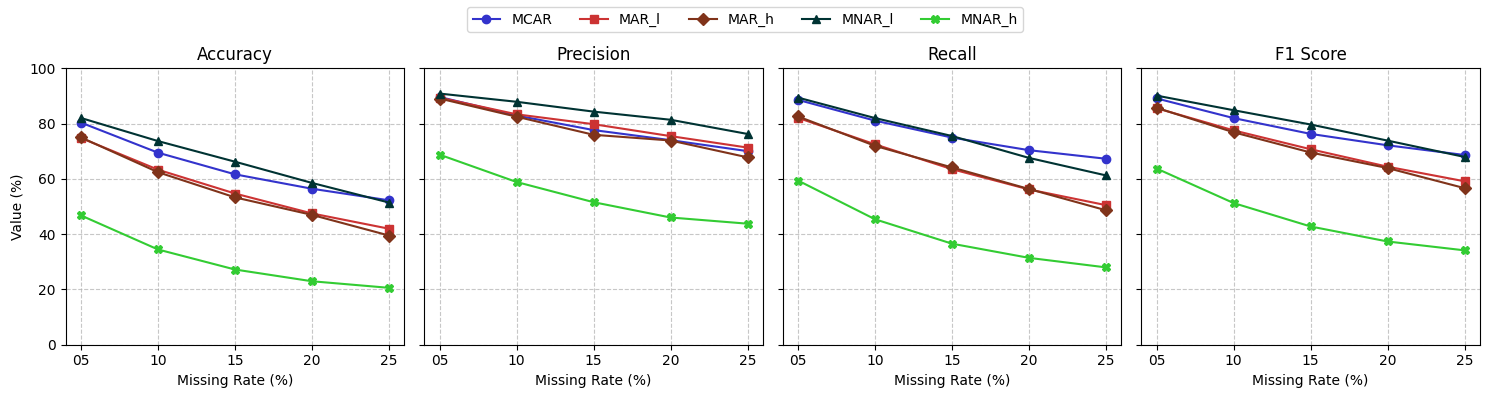

In [ ]:
# Trocar o eixo x para mostrar as métricas e cada linha ser um mecanismo
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

colors = {'MCAR': (0.2, 0.2, 0.8), 'MAR_l': (0.8, 0.2, 0.2), 
          'MAR_h': (0.5, 0.2, 0.1),'MNAR_l': (0.0, 0.2, 0.2), 'MNAR_h':(0.2, 0.8, 0.2)}
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_h': 'D', 'MNAR_l': '^', 'MNAR_h': 'X'}

fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for idx, metric in enumerate(metric_names):
    for mec_name, table in metrics_table_mec.items():
        axs[idx].plot(table['MR'], table[metric], marker=markers.get(mec_name, 'o'), label=mec_name, color=colors.get(mec_name, 'black'))
    axs[idx].set_title(metric)
    axs[idx].set_ylim(0, 100)
    axs[idx].set_xticks(mr_values)
    # axs[idx].set_xlabel('Missing Rate (%)')
    axs[idx].set_ylabel('Value (%)' if idx == 0 else "")
    axs[idx].grid(True)

fig.supxlabel('Missing Rate (%)', fontsize=10, y=0.05)

# Apenas uma legenda centralizada acima dos subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, fontsize=10)
for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('Plots/metrics_HROS_cont.png', dpi=600, bbox_inches='tight')
plt.show()

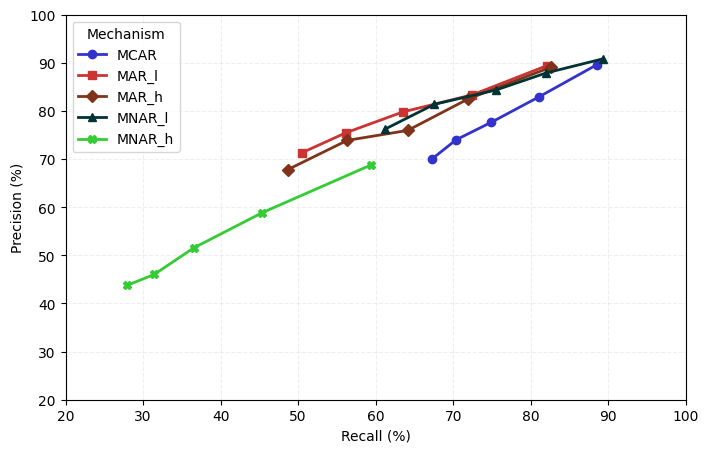

In [10]:
plt.figure(figsize=(8, 5))

for mec_name, table in metrics_table_mec.items():
    plt.plot(table['Recall'], table['Precision'], label=mec_name, marker=markers.get(mec_name, 'o'), color=colors.get(mec_name, 'black'), linewidth=2)
    # for i, row in table.iterrows():
    #     if mec_name == 'MAR':
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, 7), ha='center', fontsize=8)
    #     elif mec_name == 'MCAR':
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8)
    #     else:
    #         plt.annotate(f"{100 - int(row['MR'])}%", (row['Recall'], row['Precision']),
    #                      textcoords="offset points", xytext=(0, -12), ha='center', fontsize=8)
plt.xlabel('Recall (%)')
plt.ylabel('Precision (%)')
plt.ylim(20, 100)
plt.xlim(20,100)
plt.grid(True, linestyle='--', alpha=0.2)
plt.legend(loc='upper left', title='Mechanism')
plt.savefig('Plots/pr_plot_hros.png', dpi=300, bbox_inches='tight')
plt.show()

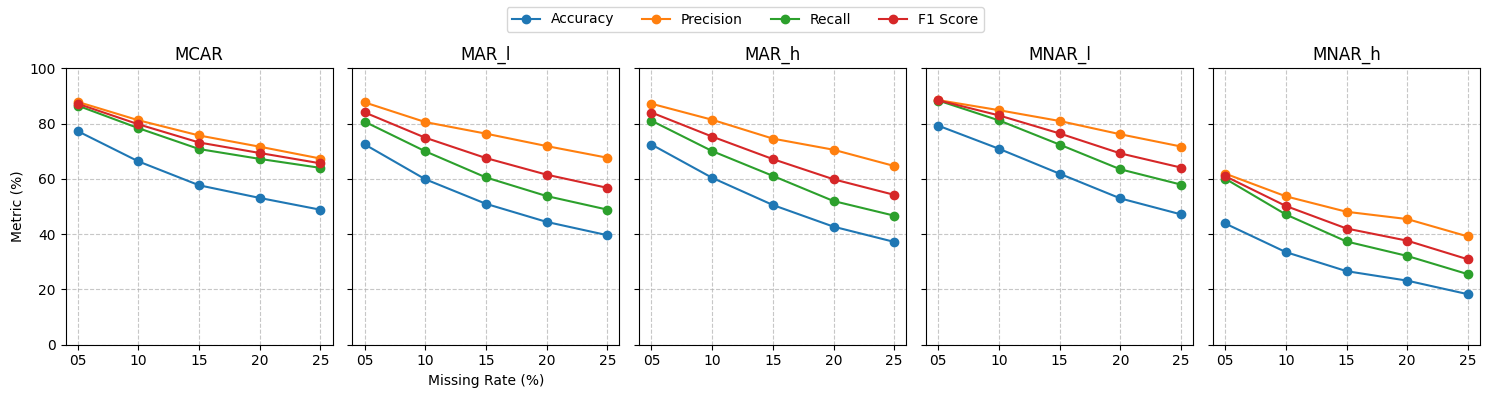

In [22]:
fig, axs = plt.subplots(1, 5, figsize=(15, 4), sharey=True)

for idx, (mec_name, table) in enumerate(metrics_table_mec.items()):
    axs[idx].plot(table['MR'], table['Accuracy'], marker='o', label='Accuracy')
    axs[idx].plot(table['MR'], table['Precision'], marker='o', label='Precision')
    axs[idx].plot(table['MR'], table['Recall'], marker='o', label='Recall')
    axs[idx].plot(table['MR'], table['F1 Score'], marker='o', label='F1 Score')
    axs[idx].set_title(mec_name)
    axs[idx].set_ylim(0, 100)
    axs[idx].set_xticks(mr_values)
    if idx == 1:
        axs[idx].set_xlabel('Missing Rate (%)')
    axs[idx].set_ylabel('Metric (%)' if idx == 0 else "")
    axs[idx].grid(True)

# Apenas uma legenda centralizada acima dos subplots
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=10)
for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('Plots/metrics_by_mechanism.png', dpi=300, bbox_inches='tight')
plt.show()